In [2]:
import warnings
warnings.filterwarnings('ignore')
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix


In [3]:
df =pd.read_csv("sales.csv")
df


,TV_Ads,Radio_Ads,Newspaper_Ads,Online_Ads,Store_Visits,Discount,Sales
0,109,24,17,45,833,9,2881
1,171,25,12,27,1468,29,4041
2,180,31,27,61,1010,17,3904
3,197,37,25,63,1816,17,5904
4,95,29,27,33,1543,16,4088
5,64,42,23,97,781,25,2606
6,202,19,16,21,1296,7,4230
7,271,49,22,56,1524,14,5697
8,255,41,10,88,618,7,5030
9,248,42,22,57,1558,16,5458


In [4]:
df.ndim

2

In [5]:
df.size

420

In [6]:
df.head(10)


,TV_Ads,Radio_Ads,Newspaper_Ads,Online_Ads,Store_Visits,Discount,Sales
0,109,24,17,45,833,9,2881
1,171,25,12,27,1468,29,4041
2,180,31,27,61,1010,17,3904
3,197,37,25,63,1816,17,5904
4,95,29,27,33,1543,16,4088
5,64,42,23,97,781,25,2606
6,202,19,16,21,1296,7,4230
7,271,49,22,56,1524,14,5697
8,255,41,10,88,618,7,5030
9,248,42,22,57,1558,16,5458


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60 entries, 0 to 59
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   TV_Ads         60 non-null     int64
 1   Radio_Ads      60 non-null     int64
 2   Newspaper_Ads  60 non-null     int64
 3   Online_Ads     60 non-null     int64
 4   Store_Visits   60 non-null     int64
 5   Discount       60 non-null     int64
 6   Sales          60 non-null     int64
dtypes: int64(7)
memory usage: 3.4 KB


In [8]:
df.describe()

,TV_Ads,Radio_Ads,Newspaper_Ads,Online_Ads,Store_Visits,Discount,Sales
count,60.000000,60.000000,60.000000,60.000000,60.000000,60.000000,60.000000
mean,173.800000,29.116667,16.883333,58.366667,1315.100000,12.400000,4734.183333
std,74.461638,11.548118,7.474457,24.789259,429.484701,8.238397,1404.659757
min,58.000000,11.000000,5.000000,20.000000,585.000000,0.000000,1239.000000
25%,112.750000,20.000000,9.750000,35.250000,915.250000,6.500000,3833.750000
50%,173.000000,28.500000,17.000000,58.000000,1443.000000,12.000000,4857.000000
75%,239.750000,40.250000,23.000000,80.250000,1707.250000,17.250000,5698.250000
max,298.000000,49.000000,28.000000,99.000000,1951.000000,29.000000,7413.000000


In [9]:
print("Checking for Missing Values")
print(df.isnull().sum())

Checking for Missing Values
TV_Ads           0
Radio_Ads        0
Newspaper_Ads    0
Online_Ads       0
Store_Visits     0
Discount         0
Sales            0
dtype: int64


In [10]:
print("Removing Duplicates")
df = df.drop_duplicates()
df

Removing Duplicates


,TV_Ads,Radio_Ads,Newspaper_Ads,Online_Ads,Store_Visits,Discount,Sales
0,109,24,17,45,833,9,2881
1,171,25,12,27,1468,29,4041
2,180,31,27,61,1010,17,3904
3,197,37,25,63,1816,17,5904
4,95,29,27,33,1543,16,4088
5,64,42,23,97,781,25,2606
6,202,19,16,21,1296,7,4230
7,271,49,22,56,1524,14,5697
8,255,41,10,88,618,7,5030
9,248,42,22,57,1558,16,5458


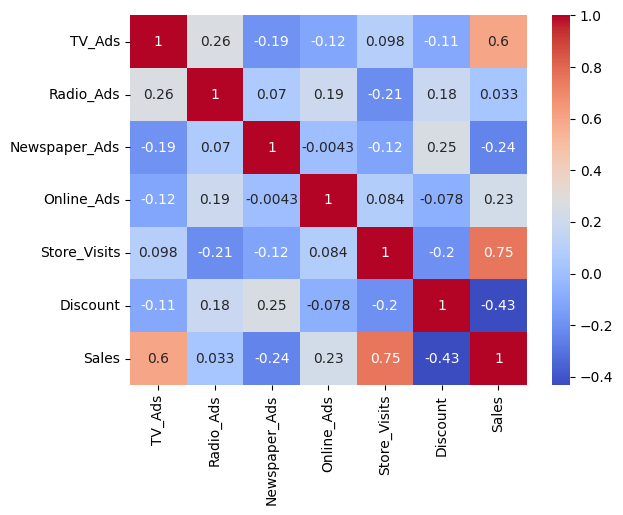

In [11]:

sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.show()

In [12]:
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler


In [13]:
df = pd.read_csv("sales.csv")
X = df.drop("Sales", axis=1)   
y = df["Sales"]               

In [14]:
mm = MinMaxScaler()
scaled_features = mm.fit_transform(X)
scaled_data = pd.DataFrame(scaled_features, columns=X.columns)
print("MinMax Scaled Data :")
print(scaled_data)

MinMax Scaled Data :
      TV_Ads  Radio_Ads  Newspaper_Ads  Online_Ads  Store_Visits  Discount
0   0.212500   0.342105       0.521739    0.316456      0.181552  0.310345
1   0.470833   0.368421       0.304348    0.088608      0.646413  1.000000
2   0.508333   0.526316       0.956522    0.518987      0.311127  0.586207
3   0.579167   0.684211       0.869565    0.544304      0.901171  0.586207
4   0.154167   0.473684       0.956522    0.164557      0.701318  0.551724
5   0.025000   0.815789       0.782609    0.974684      0.143485  0.862069
6   0.600000   0.210526       0.478261    0.012658      0.520498  0.241379
7   0.887500   1.000000       0.739130    0.455696      0.687408  0.482759
8   0.820833   0.789474       0.217391    0.860759      0.024158  0.241379
9   0.791667   0.815789       0.739130    0.468354      0.712299  0.551724
10  0.033333   0.000000       0.782609    0.506329      0.081991  0.379310
11  0.487500   0.815789       0.913043    0.772152      0.292094  0.896552
12  

In [22]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.feature_selection import SelectKBest, f_regression

In [23]:
ss=StandardScaler()
scaled_features = ss.fit_transform(X)
scaled_data = pd.DataFrame(scaled_features, columns=X.columns)
print("Standard scaled Data :")
print(scaled_data)

Standard scaled Data :
      TV_Ads  Radio_Ads  Newspaper_Ads  Online_Ads  Store_Visits  Discount
0  -0.877591  -0.446813       0.015740   -0.543762     -1.131981 -0.416184
1  -0.037921  -0.359488      -0.658850   -1.276011      0.359012  2.031959
2   0.083967   0.164462       1.364921    0.107125     -0.716381  0.563073
3   0.314199   0.688412       1.095085    0.188486      1.176124  0.563073
4  -1.067194  -0.010188       1.364921   -1.031928      0.535114  0.440666
5  -1.487029   1.125037       0.825249    1.571623     -1.254078  1.542330
6   0.381914  -0.883438      -0.119178   -1.520094     -0.044847 -0.660999
7   1.316386   1.736311       0.690331   -0.096277      0.490502  0.195851
8   1.099697   1.037712      -0.928686    1.205498     -1.636805 -0.660999
9   1.004896   1.125037       0.690331   -0.055597      0.570334  0.440666
10 -1.459943  -1.582037       0.825249    0.066445     -1.451312 -0.171370
11  0.016252   1.125037       1.230003    0.920735     -0.777430  1.664738
12

In [24]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print("R2 Score:", r2_score(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))

R2 Score: 0.9602691414387735
RMSE: 291.88642324260746


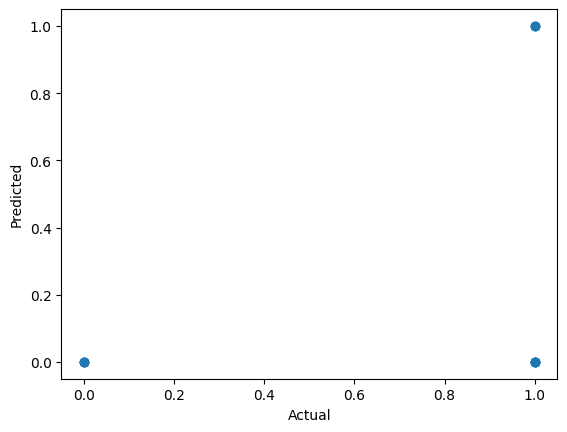

In [32]:
plt.scatter(y_test, y_pred)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.show()

In [31]:
threshold = df["Sales"].median()
df["Sales_Class"] = (df["Sales"] > threshold).astype(int)

X = df.drop(["Sales","Sales_Class"], axis=1)
y = df["Sales_Class"]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

coefficients = pd.DataFrame({"Feature": X.columns, "Coefficient": model.coef_[0]})
print(coefficients)

[[4 0]
 [5 3]]
              precision    recall  f1-score   support

           0       0.44      1.00      0.62         4
           1       1.00      0.38      0.55         8

    accuracy                           0.58        12
   macro avg       0.72      0.69      0.58        12
weighted avg       0.81      0.58      0.57        12

         Feature  Coefficient
0         TV_Ads     1.776302
1      Radio_Ads     0.216584
2  Newspaper_Ads    -0.461791
3     Online_Ads     0.749752
4   Store_Visits     1.428175
5       Discount    -0.926904


In [27]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

In [28]:
print(df)
x = df.iloc[:,:-1]
y = df.iloc[:,-1]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,random_state=42)


    TV_Ads  Radio_Ads  Newspaper_Ads  Online_Ads  Store_Visits  Discount  \
0      109         24             17          45           833         9   
1      171         25             12          27          1468        29   
2      180         31             27          61          1010        17   
3      197         37             25          63          1816        17   
4       95         29             27          33          1543        16   
5       64         42             23          97           781        25   
6      202         19             16          21          1296         7   
7      271         49             22          56          1524        14   
8      255         41             10          88           618         7   
9      248         42             22          57          1558        16   
10      66         11             23          60           697        11   
11     175         42             26          81           984        26   
12     285  

In [29]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)


,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [30]:
y_pred = knn.predict(X_test)
y_test

0     2881
5     2606
36    5263
45    6120
13    3478
54    5495
33    2516
48    5702
12    7275
57    5269
46    5507
50    5223
Name: Sales, dtype: int64

In [21]:

print(confusion_matrix(y_test, y_pred))


[[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0]]


In [22]:
print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

        1239       0.00      0.00      0.00       0.0
        2516       0.00      0.00      0.00       1.0
        2606       0.00      0.00      0.00       1.0
        2728       0.00      0.00      0.00       0.0
        2881       0.00      0.00      0.00       1.0
        3478       0.00      0.00      0.00       1.0
        3707       0.00      0.00      0.00       0.0
        4041       0.00      0.00      0.00       0.0
        4585       0.00      0.00      0.00       0.0
        4655       0.00      0.00      0.00       0.0
        4673       0.00      0.00      0.00       0.0
        5223       0.00      0.00      0.00       1.0
        5263       0.00      0.00      0.00       1.0
        5269       0.00      0.00      0.00       1.0
        5458       0.00      0.00      0.00       0.0
        5495       0.00      0.00      0.00       1.0
        5507       0.00      0.00      0.00       1.0
        5702       0.00    